In [6]:
# One Hot Encoding Dictionary

encoding = {
    'A': [1,0,0,0],
    'T': [0,1,0,0],
    'G': [0,0,1,0],
    'C': [0,0,0,1]
}

# Function to encode DNA sequence

def encode_sequence(seq):

    encoded = []

    for nucleotide in seq:

        if nucleotide in encoding:

            encoded.extend(encoding[nucleotide])

    return encoded

In [17]:
from Bio import Entrez

Entrez.email = "riyanarednragupta@gmail.com"

search_handle = Entrez.esearch(
    db="nucleotide",
    term="Homo sapiens cancer gene mRNA",
    retmax=10
)

search_results = Entrez.read(search_handle)

gene_ids = search_results["IdList"]

print("Found IDs:")
print(gene_ids)

Found IDs:
['1676325097', '1676318478', '1519314775', '1519312768', '1475928913', '1475928813', '822606578', '787168301', '1890267481', '1889697436']


In [19]:
from Bio import SeqIO

cancer_sequences = []

for gene_id in gene_ids:

    try:

        handle = Entrez.efetch(
            db="nucleotide",
            id=gene_id,
            rettype="fasta",
            retmode="text"
        )

        record = SeqIO.read(handle, "fasta")

        seq = str(record.seq)

        # Keep sequences longer than 200 bases
        if len(seq) > 200:

            cancer_sequences.append(seq)

            print("\nDownloaded:", record.id)
            print("Length:", len(seq))
            print("First 50 bases:")
            print(seq[:50])

    except Exception as e:

        print("Error with:", gene_id)
        print(e)

print("\nTotal downloaded cancer sequences:")
print(len(cancer_sequences))


Downloaded: NM_001287181.2
Length: 2002
First 50 bases:
ATCCTGGGGAACAGGACTGCTAGCAGTAAAGATGGGGGAGCCAGGGCCCC

Downloaded: NM_182791.4
Length: 2104
First 50 bases:
ATCCTGGGGAACAGGACTGCTAGCAGTAAAGATGGGGGAGCCAGGGCCCC

Downloaded: NM_025055.5
Length: 2750
First 50 bases:
ATTGTTTTCCAGGCCTGGGCAGAGACAGGGCCCCCCTGCCCCATCTCTCC

Downloaded: NM_005215.4
Length: 10181
First 50 bases:
GCACACCGCTGGCGGACACCCCAGTAACAAGTGAGAGCGCTCCACCCCGC

Downloaded: NM_001320766.2
Length: 7635
First 50 bases:
AGAAGCCGGAAGTTGTGTCCCGGACGTGTCAACCGGGGTCTGAGTGCTCA

Downloaded: NM_015565.3
Length: 7677
First 50 bases:
AGAAGCCGGAAGTTGTGTCCCGGACGTGTCAACCGGGGTCTGAGTGCTCA

Downloaded: NM_004442.7
Length: 11057
First 50 bases:
CATTCTGCTGGCTGCGCGGTGGCGGCGGCTGTGTGTGCGCCGCGCCTTGC

Downloaded: NG_011804.2
Length: 217663
First 50 bases:
ATTTATGCAGCCAATAGACACAGGAAAAAATGCTCATCATCACTGGCCAT

Downloaded: NM_014725.5
Length: 4861
First 50 bases:
GGTGGCCTTCCAGGAGGCGGGAGGCGCCCGCTGTCGAGGCAGCTGAGCCC

Downloaded: NM_001142503.3
Length: 4943
Firs

In [20]:
search_handle = Entrez.esearch(
    db="nucleotide",
    term="Homo sapiens metabolism gene mRNA",
    retmax=10
)

search_results = Entrez.read(search_handle)

metabolism_ids = search_results["IdList"]

print("Metabolism IDs:\n")

print(metabolism_ids)

Metabolism IDs:

['3334882212', '3334879460', '3334878529', '3334876471', '3334873922', '3334873666', '3334870723', '3334866281', '2580012632', '1676446580']


In [21]:
metabolism_sequences = []

for gene_id in metabolism_ids:

    try:

        handle = Entrez.efetch(
            db="nucleotide",
            id=gene_id,
            rettype="fasta",
            retmode="text"
        )

        record = SeqIO.read(handle, "fasta")

        seq = str(record.seq)

        if len(seq) > 200:

            metabolism_sequences.append(seq)

            print("\nDownloaded:", record.id)
            print("Length:", len(seq))
            print("First 50 bases:")
            print(seq[:50])

    except Exception as e:

        print("Error with:", gene_id)
        print(e)

print("\nTotal downloaded metabolism sequences:")
print(len(metabolism_sequences))


Downloaded: JBWZLD010000001.1
Length: 1475243
First 50 bases:
AAGGGTTAAAAATTATTATAAGGCCTTATAATTTATATAGGGATTTTTAT

Downloaded: JBWZLD010000004.1
Length: 1246043
First 50 bases:
TATTTATAATAATTATTATATTATAAAATAAGCTATATTTAATTATATAT

Downloaded: JBWZLD010000005.1
Length: 1055787
First 50 bases:
GCCCCCCGCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC

Downloaded: JBWZLD010000008.1
Length: 861646
First 50 bases:
TTAATTTATATATAATTTATATATAAATAATTTATTATATAAAAAGCTTT

Downloaded: JBWZLD010000013.1
Length: 644062
First 50 bases:
ATCCCCACCAAGATTCTTCTCGAAGACGCTTAGTTGGTGGACGCCCTGCT

Downloaded: JBWZLD010000014.1
Length: 639528
First 50 bases:
TAGGTATTTAAGTTATATTTATTTATAATTATTATTATTATAAGGTAATA

Downloaded: JBWZLD010000024.1
Length: 433416
First 50 bases:
TATTTTAATTATTTTAAAGTAATATAAAAGTATTATTTATTATAATTAAT

Downloaded: JBWZLD010000046.1
Length: 299300
First 50 bases:
TATTATTATTAAGACTATTAAGATTTAATTAAAATACTTTAATCCCTATT

Downloaded: NR_188533.1
Length: 2048
First 50 bases:
GCAGTGTGGAGGCGCTGAGGCTGCTGGAGGCGCGGGCCG

In [22]:
sequences = []
labels = []

# Add cancer genes
for seq in cancer_sequences:

    sequences.append(seq[:100])

    labels.append("cancer")

# Add metabolism genes
for seq in metabolism_sequences:

    sequences.append(seq[:100])

    labels.append("metabolism")

print("Total sequences:", len(sequences))

print("Total labels:", len(labels))

print("\nExample label list:")
print(labels[:5])

Total sequences: 20
Total labels: 20

Example label list:
['cancer', 'cancer', 'cancer', 'cancer', 'cancer']


In [23]:
X = []

for seq in sequences:

    encoded = encode_sequence(seq)

    X.append(encoded)

print("Encoded sequences:", len(X))

print("Length of one encoded sequence:")
print(len(X[0]))

Encoded sequences: 20
Length of one encoded sequence:
400


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(labels)

print("Encoded labels:")
print(y)

Encoded labels:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [27]:
predictions = model.predict(X_test)

print("Predictions:")
print(predictions)

print("\nActual labels:")
print(y_test)

Predictions:
[0 1 1 0]

Actual labels:
[0 1 1 0]


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


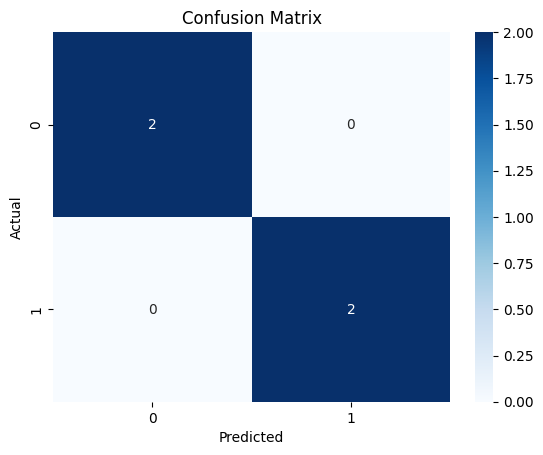

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()